# ipynb/single_umap.ipynb - 单模型 UMAP / Single-model UMAP

## 项目背景 / Background
单模型 UMAP
Single-model UMAP

## 功能模块 / Modules
- 单模型特征 UMAP 嵌入可视化
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: collect_*.py、prepare_umap_*.py
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



In [ ]:
# --- 0. 环境准备 ---
library(reticulate)
library(uwot)
library(ggplot2)
library(dplyr)
library(scales)

# --- 1. 定义基于核苷酸分组的排序和配色 ---

# 1.1 定义分组顺序 (这是实现图例分组的关键)
# 我们将按照 A -> C -> G -> U 的顺序手动排列 12 个 Label
grouped_levels <- c(
  # === A Group (5个) ===
  "Am", "Atol", "m1A", "m6A", "m6Am",
  # === C Group (3个) ===
  "Cm", "ac4C", "m5C",
  # === G Group (2个) ===
  "Gm", "m7G",
  # === U Group (2个) ===
  "Tm", "Y"
)

# 1.2 定义对应颜色 (Name = Color)
nucleotide_colors <- c(
  # A Group: Red/Rose
  "Am" = "#E6A0A0", "Atol" = "#D47F7F", "m1A" = "#C25E5E", "m6A" = "#B03C3C", "m6Am" = "#8F2525",
  # C Group: Blue/Slate
  "Cm" = "#A3C4D9", "ac4C" = "#7AA6C2", "m5C" = "#5188AB",
  # G Group: Green
  "Gm" = "#A8CFA0", "m7G" = "#6B9E60",
  # U Group: Yellow/Earth
  "Tm" = "#E6CF95", "Y" = "#C4AA6E"
)

# 原始标签名称 (用于索引映射 0-11 -> Name)
# 注意：这里的顺序必须对应 Python 代码中生成 label 时的 0-11 顺序，不能乱改
label_names_original_order <- c("Am", "Atol", "Cm", "Gm", "Tm", "Y", "ac4C", "m1A", "m5C", "m6A", "m6Am", "m7G")

# --- 2. 数据加载 ---
np <- import("numpy")
data_npz <- np$load('data/human_atten.npz')

raw_attn <- data_npz$f[['attn_out_12']]
raw_labels_input <- data_npz$f[['label12']]

# --- 3. 标签处理与纯净筛选 ---
labels_final <- NULL

# 兼容 1D 和 2D 标签格式
if (length(dim(raw_labels_input)) == 2) {
  cat("检测到 2D 标签矩阵，执行单标签纯净筛选...\n")
  row_sums <- rowSums(raw_labels_input)
  pure_indices <- which(row_sums == 1)
  
  # 筛选特征
  n_samples <- dim(raw_attn)[1]
  mat_full <- array_reshape(raw_attn, c(n_samples, dim(raw_attn)[2] * dim(raw_attn)[3]))
  mat_full <- mat_full[pure_indices, ]
  
  # 筛选标签并转为 0-11 索引
  raw_labels_subset <- raw_labels_input[pure_indices, ]
  labels_final <- max.col(raw_labels_subset) - 1 
  
} else {
  cat("检测到 1D 标签向量，直接使用...\n")
  n_samples <- dim(raw_attn)[1]
  mat_full <- array_reshape(raw_attn, c(n_samples, dim(raw_attn)[2] * dim(raw_attn)[3]))
  labels_final <- as.integer(raw_labels_input)
}

# --- 4. 均衡采样 ---
plot_indices_subset <- c()
plot_labels_name <- c()
n_per_class <- 2000 

set.seed(42)
print("开始采样...")

for (i in 0:11) {
  # 这里必须用原始顺序找到对应的名称
  target_name <- label_names_original_order[i + 1]
  
  curr_indices <- which(labels_final == i)
  if (length(curr_indices) > 0) {
    n_take <- min(length(curr_indices), n_per_class)
    sampled_idx <- sample(curr_indices, n_take)
    
    plot_indices_subset <- c(plot_indices_subset, sampled_idx)
    plot_labels_name <- c(plot_labels_name, rep(target_name, n_take))
  }
}

mat_for_umap <- mat_full[plot_indices_subset, ]

# --- 5. 运行 UMAP ---
cat("Running Global UMAP...\n")
umap_out <- umap(mat_for_umap, n_neighbors = 30, min_dist = 0.3, metric = "cosine", n_threads = 64)

# --- 6. 构建绘图数据 (关键修改步骤) ---
plot_df <- data.frame(
  U1 = umap_out[,1],
  U2 = umap_out[,2],
  # 【关键】：在这里指定 levels = grouped_levels
  # 这会强制 ggplot 的图例按照 A -> C -> G -> U 的顺序排列
  Label = factor(plot_labels_name, levels = grouped_levels)
)

# --- 7. 绘图 ---
p <- ggplot(plot_df, aes(x = U1, y = U2, color = Label)) +
  
  geom_point(size = 0.6, alpha = 0.7, stroke = 0) +
  
  # 使用 breaks 参数可以双重保险，确保图例顺序
  scale_color_manual(values = nucleotide_colors, breaks = grouped_levels) +
  
  theme_minimal() +
  
  # 优化图例：单列显示，让分组看起来更清晰
  guides(color = guide_legend(
    override.aes = list(size = 4, alpha = 1),
    ncol = 1  # 强制图例为单列，这样 A/C/G/U 就会从上到下依次排列
  )) +
  
  labs(
    title = "Global UMAP of RNA Modifications",
    subtitle = "Legend ordered by Nucleotide Group: A \u2192 C \u2192 G \u2192 U", # 提示阅读顺序
    x = "UMAP Dimension 1", 
    y = "UMAP Dimension 2",
    color = "Mod Group"
  ) +
  
  theme(
    panel.grid = element_blank(),
    plot.background = element_rect(fill = "#F9F8F7", color = NA),
    axis.text = element_blank(), 
    axis.ticks = element_blank(),
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
    
    # 调整图例背景和间距
    legend.position = "right",
    legend.key.height = unit(0.6, "cm"), # 增加一点行高，让分组更容易看清
    legend.text = element_text(size = 11),
    legend.title = element_text(face="bold")
  )

print(p)
ggsave("png/UMAP_Grouped_Legend.pdf", p, width = 11, height = 9, device = cairo_pdf)

<U+68C0><U+6D4B><U+5230> 2D <U+6807><U+7B7E><U+77E9><U+9635><U+FF0C><U+6267><U+884C><U+7EAF><U+51C0><U+6837><U+672C><U+7B5B><U+9009>...
<U+7EAF><U+51C0><U+7B5B><U+9009><U+540E><U+6837><U+672C><U+603B><U+6570>: 173807
[1] "<U+6B63><U+5728><U+6267><U+884C><U+91C7><U+6837><U+FF0C><U+76EE><U+6807><U+6BCF><U+7C7B><U+6570><U+91CF>: 3000"

=== <U+6700><U+7EC8><U+8FDB><U+5165><U+7ED8><U+56FE><U+7684><U+5404><U+7C7B><U+522B><U+6837><U+672C><U+6570><U+91CF> ===
   Class Count
1     Am  1536
2   Atol  3000
3     Cm  1811
4     Gm  1428
5     Tm  2159
6      Y  3000
7   ac4C  3000
8    m1A  3000
9    m5C  3000
10   m6A  3000
11  m6Am  2221
12   m7G  1508

Running UMAP on 28663 samples...
[1] "<U+5F00><U+59CB><U+5206><U+5C42><U+7ED8><U+56FE>..."


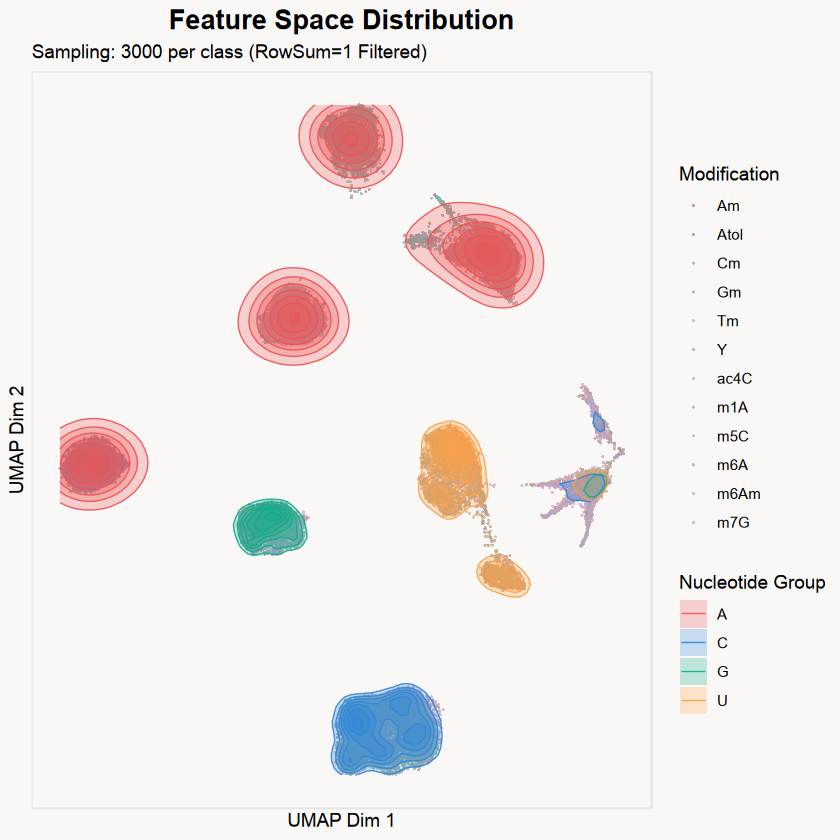

In [8]:
# ==============================================================================
# 最终版：纯净筛选 -> 【按需采样】 -> 分层绘制密度图
# ==============================================================================

# --- 0. 环境准备 ---
library(reticulate)
library(uwot)
library(ggplot2)
library(dplyr)
library(scales)
if (!require("ggnewscale")) install.packages("ggnewscale")
library(ggnewscale)

# ==========================================
# 【关键参数设置】
# 1000 = 每个类别最多采 1000 个
# Inf  = 使用所有样本 (不采样)
n_sample_per_class <- 3000
# ==========================================

# --- 1. 配色与定义 ---
morandi_colors <- c(
  "Am" = "#B9837D", "Atol" = "#7A9CC6", "Cm" = "#8FA68E", 
  "Gm" = "#A090B8", "Tm" = "#D4B082", "Y" = "#B8A08C",
  "ac4C" = "#D6A3B8", "m1A" = "#7DB5B5", "m5C" = "#9BB89C", 
  "m6A" = "#B89595", "m6Am" = "#A3B8C7", "m7G" = "#B8A8C5"
)

group_colors <- c(
  "A" = "#EE5253", # 红
  "C" = "#2E86DE", # 蓝
  "G" = "#10AC84", # 绿
  "U" = "#FF9F43"  # 橙
)

label_names_original_order <- c("Am", "Atol", "Cm", "Gm", "Tm", "Y", "ac4C", "m1A", "m5C", "m6A", "m6Am", "m7G")

group_mapping <- list(
  "A" = c("Am", "Atol", "m1A", "m6A", "m6Am"),
  "C" = c("Cm", "ac4C", "m5C"),
  "G" = c("Gm", "m7G"),
  "U" = c("Tm", "Y")
)

# --- 2. 数据加载 ---
np <- import("numpy")
data_npz <- np$load('data/human_atten.npz')

raw_attn <- data_npz$f[['attn_out_12']]
raw_labels_input <- data_npz$f[['label12']]

n_total <- dim(raw_attn)[1]
mat_full_raw <- array_reshape(raw_attn, c(n_total, dim(raw_attn)[2] * dim(raw_attn)[3]))

# --- 3. 纯净样本筛选 (Step 1: Filtering) ---
# 先拿到所有的纯净样本
mat_pure <- NULL
labels_pure_idx <- NULL

if (length(dim(raw_labels_input)) == 2) {
  cat("检测到 2D 标签矩阵，执行纯净样本筛选...\n")
  row_sums <- rowSums(raw_labels_input)
  pure_indices <- which(row_sums == 1)
  mat_pure <- mat_full_raw[pure_indices, ]
  raw_labels_subset <- raw_labels_input[pure_indices, ]
  labels_pure_idx <- max.col(raw_labels_subset) - 1 
} else {
  mat_pure <- mat_full_raw
  labels_pure_idx <- as.integer(raw_labels_input)
}

cat(sprintf("纯净筛选后样本总数: %d\n", nrow(mat_pure)))

# --- 4. 按类别采样 (Step 2: Sampling) ---
# 基于 n_sample_per_class 进行二次筛选
final_indices_keep <- c()
set.seed(42) # 保证采样结果可复现

print(paste("正在执行采样，目标每类数量:", n_sample_per_class))

for (i in 0:11) {
  # 找到当前类别在 mat_pure 中的行号
  curr_class_indices <- which(labels_pure_idx == i)
  n_avail <- length(curr_class_indices)
  
  if (n_avail > 0) {
    if (is.infinite(n_sample_per_class)) {
      # 如果是 Inf，全取
      final_indices_keep <- c(final_indices_keep, curr_class_indices)
    } else {
      # 如果是具体数字，采样
      n_take <- min(n_avail, n_sample_per_class)
      sampled <- sample(curr_class_indices, n_take)
      final_indices_keep <- c(final_indices_keep, sampled)
    }
  }
}

# 更新最终用于 UMAP 的数据
mat_final <- mat_pure[final_indices_keep, ]
labels_final_idx <- labels_pure_idx[final_indices_keep]

# 转换名称
final_names_vec <- label_names_original_order[labels_final_idx + 1]

# --- 5. 打印最终统计 ---
cat("\n=== 最终进入绘图的各类别样本数量 ===\n")
counts_df <- as.data.frame(table(factor(final_names_vec, levels = label_names_original_order)))
colnames(counts_df) <- c("Class", "Count")
print(counts_df)
cat("========================================\n")

# --- 6. 运行 UMAP ---
cat(sprintf("\nRunning UMAP on %d samples...\n", nrow(mat_final)))
umap_out <- umap(mat_final, n_neighbors = 30, min_dist = 0.3, metric = "cosine", n_threads = 64)

# --- 7. 构建数据 ---
plot_df <- data.frame(
  U1 = umap_out[,1],
  U2 = umap_out[,2],
  Label = factor(final_names_vec, levels = label_names_original_order)
)

get_group <- function(label) {
  label <- trimws(as.character(label))
  for (g in names(group_mapping)) {
    if (label %in% group_mapping[[g]]) return(g)
  }
  return(NA)
}
plot_df$Group <- sapply(plot_df$Label, get_group)
plot_df$Group <- factor(plot_df$Group, levels = c("A", "C", "G", "U"))

# --- 8. 分层绘图 ---
print("开始分层绘图...")

p <- ggplot(plot_df, aes(x = U1, y = U2)) +
  
  # === Layer 1: 底层散点 ===
  geom_point(aes(color = Label), size = 0.6, alpha = 0.7, stroke = 0) +
  scale_color_manual(values = morandi_colors, name = "Modification") +
  
  new_scale_color() +
  
  # === Layer 2: 密度填充 (分 4 组独立绘制) ===
  # Group A
  stat_density_2d(data = subset(plot_df, Group == "A"),
                  geom = "polygon", aes(fill = Group), alpha = 0.25, bins = 8, color = NA) +
  # Group C
  stat_density_2d(data = subset(plot_df, Group == "C"),
                  geom = "polygon", aes(fill = Group), alpha = 0.25, bins = 8, color = NA) +
  # Group G
  stat_density_2d(data = subset(plot_df, Group == "G"),
                  geom = "polygon", aes(fill = Group), alpha = 0.25, bins = 8, color = NA) +
  # Group U
  stat_density_2d(data = subset(plot_df, Group == "U"),
                  geom = "polygon", aes(fill = Group), alpha = 0.25, bins = 8, color = NA) +
  
  scale_fill_manual(values = group_colors, name = "Nucleotide Group", drop = FALSE) +
  
  # === Layer 3: 等高线 (分 4 组独立绘制) ===
  stat_density_2d(data = subset(plot_df, Group == "A"),
                  geom = "path", aes(color = Group), size = 0.3, alpha = 0.9, bins = 8) +
  stat_density_2d(data = subset(plot_df, Group == "C"),
                  geom = "path", aes(color = Group), size = 0.3, alpha = 0.9, bins = 8) +
  stat_density_2d(data = subset(plot_df, Group == "G"),
                  geom = "path", aes(color = Group), size = 0.3, alpha = 0.9, bins = 8) +
  stat_density_2d(data = subset(plot_df, Group == "U"),
                  geom = "path", aes(color = Group), size = 0.3, alpha = 0.9, bins = 8) +
  
  scale_color_manual(values = group_colors, name = "Nucleotide Group", drop = FALSE) +
  
  # === 主题 ===
  theme_minimal() +
  labs(
    title = "Feature Space Distribution",
    subtitle = sprintf("Sampling: %s per class (RowSum=1 Filtered)", as.character(n_sample_per_class)),
    x = "UMAP Dim 1", 
    y = "UMAP Dim 2"
  ) +
  theme(
    panel.grid = element_blank(),
    plot.background = element_rect(fill = "#F9F8F7", color = NA),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.border = element_rect(color = "grey90", fill = NA, linewidth = 0.5),
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
    legend.position = "right"
  )

print(p)
# 文件名体现采样参数
filename <- sprintf("png/UMAP_Sampled_%s.pdf", as.character(n_sample_per_class))
ggsave(filename, p, width = 12, height = 10, device = cairo_pdf)